In [8]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_csv("Iris.csv")

# Clean column names
df.columns = df.columns.str.strip()

print("Column names:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
print(df.head())

# Check missing values
print("\nMissing values:")
print(df.isnull().sum())

# Check data types
print("\nData types:")
print(df.dtypes)

# Remove Id if available
id_columns = [col for col in df.columns if col.lower() == "id"]

if id_columns:
    df = df.drop(columns=id_columns)
    print("\nId column removed.")
else:
    print("\nNo Id column found.")

# Find the species/target column automatically
possible_target_columns = ["species", "class", "target", "label", "variety"]

target_column = None

for col in df.columns:
    if col.lower() in possible_target_columns:
        target_column = col
        break

if target_column is None:
    print("\nCould not automatically find the species column.")
    print("Available columns:", df.columns.tolist())
else:
    print("\nTarget column:", target_column)
    print("Species values:")
    print(df[target_column].unique())

    # Encode species labels
    mapping = {
        "Iris-setosa": 0,
        "Iris-versicolor": 1,
        "Iris-virginica": 2
    }

    df["Target"] = df[target_column].map(mapping)

    print("\nEncoded species:")
    print(df[[target_column, "Target"]].drop_duplicates())

    # Separate features and target
    X = df.drop(columns=[target_column, "Target"])
    y = df["Target"]

    print("\nFeature columns:")
    print(X.columns.tolist())

    print("\nX shape:", X.shape)
    print("y shape:", y.shape)

Column names:
['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

First 5 rows:
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa

Missing values:
sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Data types:
sepal_length    float64
sepal_width     float64
petal_length    float64
petal_width     float64
species             str
dtype: object

No Id column found.

Target column: species
Species values:
<StringArray>
['setosa', 'versicolor', 'virginica']
Length: 3, dtype: str

Encoded species:
        species  Target
0        setosa     NaN
50   versicolor     NaN
100   virginica     N

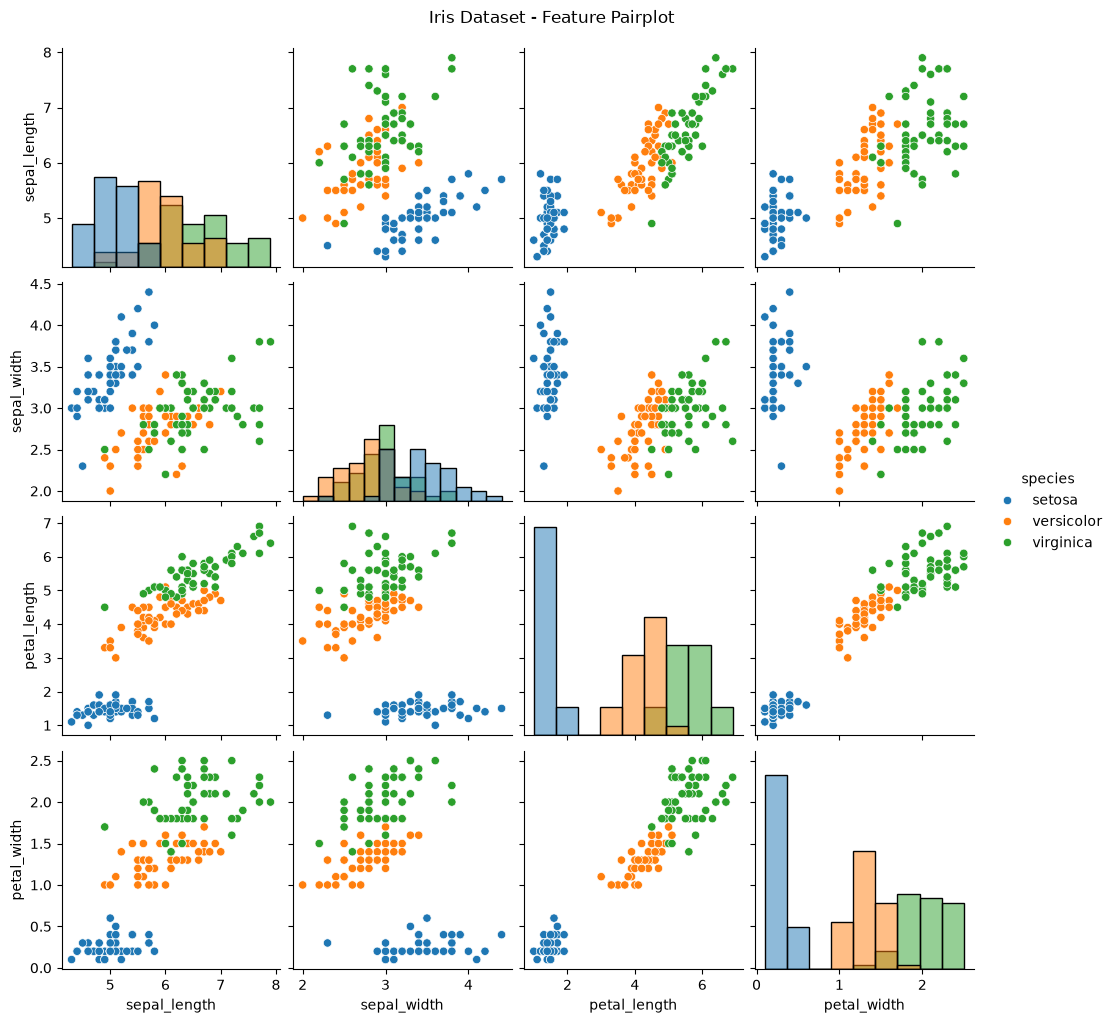


Descriptive Statistics:
       sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.054000      3.758667     1.198667
std        0.828066     0.433594      1.764420     0.763161
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.800000     3.000000      4.350000     1.300000
75%        6.400000     3.300000      5.100000     1.800000
max        7.900000     4.400000      6.900000     2.500000

Class Distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Final Dataset:
   sepal_length  sepal_width  petal_length  petal_width species  Target
0           5.1          3.5           1.4          0.2  setosa     NaN
1           4.9          3.0           1.4          0.2  setosa     NaN
2           4.7          3.2           1.3          0.2  setosa     NaN
3           4.6          

In [9]:
# ==========================================
# PART 2: VISUAL EDA
# ==========================================

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Define feature columns
feature_columns = [
    "sepal_length",
    "sepal_width",
    "petal_length",
    "petal_width"
]

# Create X if not already created
X = df[feature_columns]

# Pairplot
sns.pairplot(
    df,
    vars=feature_columns,
    hue="species",
    diag_kind="hist"
)

plt.suptitle(
    "Iris Dataset - Feature Pairplot",
    y=1.02
)

plt.show()

# ==========================================
# DESCRIPTIVE STATISTICS
# ==========================================

print("\nDescriptive Statistics:")
print(X.describe())

# ==========================================
# CLASS DISTRIBUTION
# ==========================================

print("\nClass Distribution:")
print(df["species"].value_counts())

# ==========================================
# FINAL DATASET
# ==========================================

print("\nFinal Dataset:")
print(df.head(10))

In [13]:
# ==========================================
# PART 3: TRAIN-TEST SEPARATION & SCALING
# ==========================================

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Step 1: Stratified 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

print("\nTraining target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

# Step 2: Create StandardScaler
scaler = StandardScaler()

# Step 3: FIT ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)

# Step 4: Transform test data
X_test_scaled = scaler.transform(X_test)

print("\nX_train scaled shape:", X_train_scaled.shape)
print("X_test scaled shape:", X_test_scaled.shape)

print("\nFirst 5 scaled training samples:")
print(X_train_scaled[:5])

print("\nFirst 5 scaled testing samples:")
print(X_test_scaled[:5])

Training data shape: (120, 4)
Testing data shape: (30, 4)

Training target shape: (120,)
Testing target shape: (30,)

X_train scaled shape: (120, 4)
X_test scaled shape: (30, 4)

First 5 scaled training samples:
[[-1.72156775 -0.32483982 -1.34703555 -1.32016847]
 [-1.12449223 -1.22612948  0.41429037  0.65186742]
 [ 1.14439475 -0.55016223  0.58474127  0.25746024]
 [-1.12449223  0.12580502 -1.29021859 -1.45163753]
 [-0.40800161 -1.22612948  0.13020555  0.12599118]]

First 5 scaled testing samples:
[[-1.72156775 -0.0995174  -1.40385252 -1.32016847]
 [ 0.30848902 -0.0995174   0.64155823  0.78333648]
 [-1.12449223 -1.45145189 -0.26751321 -0.268416  ]
 [-1.00507713 -1.67677431 -0.26751321 -0.268416  ]
 [-1.72156775  0.35112743 -1.40385252 -1.32016847]]


KNN (Unscaled) Accuracy: 1.0
KNN (Scaled) Accuracy: 0.9333333333333333
Decision Tree Accuracy: 0.9666666666666667


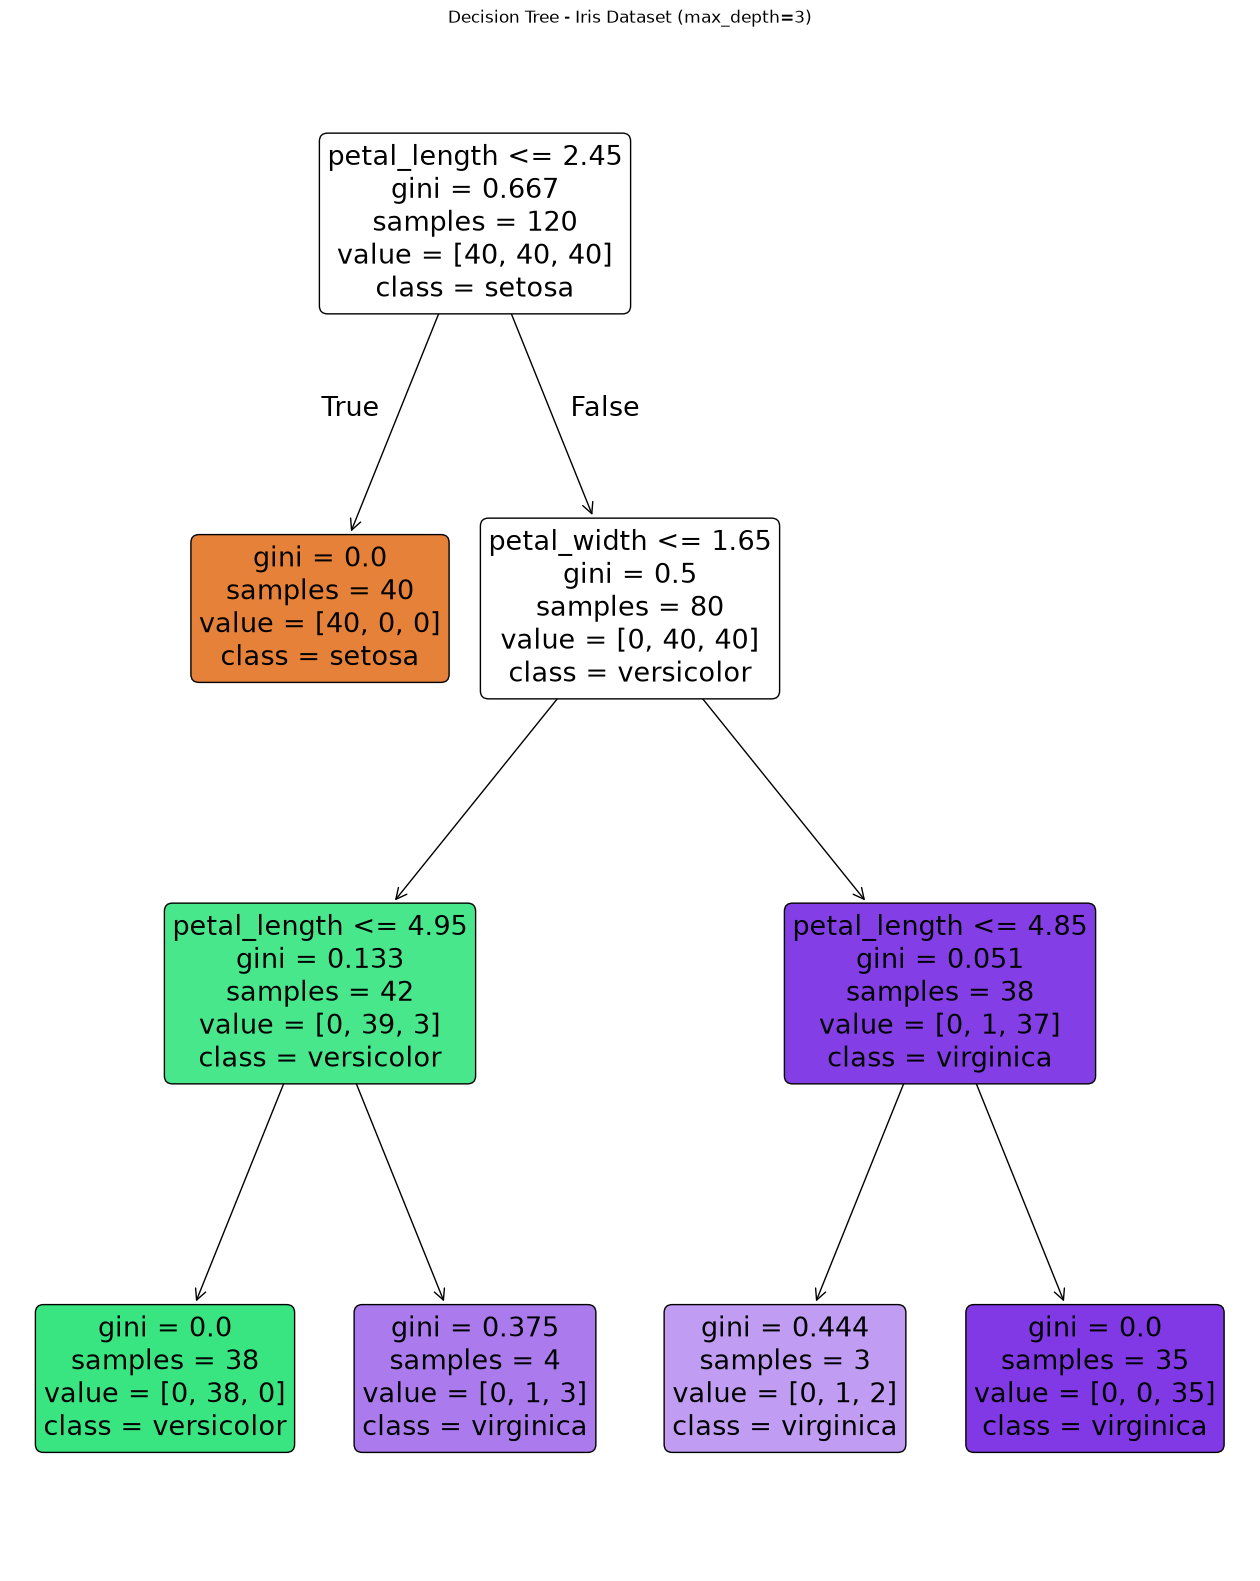

In [18]:
# ==========================================
# PART 4: MODEL COMPARISON
# KNN vs DECISION TREE
# ==========================================

from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report


# ==========================================
# MODEL A: K-NEAREST NEIGHBOURS (k=3)
# ==========================================

# ------------------------------------------
# KNN on UNSCALED data
# ------------------------------------------

knn_unscaled = KNeighborsClassifier(n_neighbors=3)

knn_unscaled.fit(X_train, y_train)

y_pred_knn_unscaled = knn_unscaled.predict(X_test)

accuracy_knn_unscaled = accuracy_score(
    y_test,
    y_pred_knn_unscaled
)

print("KNN (Unscaled) Accuracy:",
      accuracy_knn_unscaled)


# ------------------------------------------
# KNN on SCALED data
# ------------------------------------------

knn_scaled = KNeighborsClassifier(n_neighbors=3)

knn_scaled.fit(X_train_scaled, y_train)

y_pred_knn_scaled = knn_scaled.predict(X_test_scaled)

accuracy_knn_scaled = accuracy_score(
    y_test,
    y_pred_knn_scaled
)

print("KNN (Scaled) Accuracy:",
      accuracy_knn_scaled)


# ==========================================
# MODEL B: DECISION TREE
# max_depth = 3
# ==========================================

dt = DecisionTreeClassifier(
    max_depth=3,
    random_state=42
)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

accuracy_dt = accuracy_score(
    y_test,
    y_pred_dt
)

print("Decision Tree Accuracy:",
      accuracy_dt)


# ==========================================
# DECISION TREE VISUALIZATION
# ==========================================

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 20))

plot_tree(
    dt,
    feature_names=feature_columns,
    class_names=["setosa", "versicolor", "virginica"],
    filled=True,
    rounded=True
)

plt.title("Decision Tree - Iris Dataset (max_depth=3)")
plt.show()

In [20]:
# ==========================================
# CLASSIFICATION REPORTS
# ==========================================

print("\n==========================================")
print("KNN (SCALED) CLASSIFICATION REPORT")
print("==========================================")

print(classification_report(
    y_test,
    y_pred_knn_scaled,
    target_names=["setosa", "versicolor", "virginica"]
))


print("\n==========================================")
print("DECISION TREE CLASSIFICATION REPORT")
print("==========================================")

print(classification_report(
    y_test,
    y_pred_dt,
    target_names=["setosa", "versicolor", "virginica"]
))


KNN (SCALED) CLASSIFICATION REPORT
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.83      1.00      0.91        10
   virginica       1.00      0.80      0.89        10

    accuracy                           0.93        30
   macro avg       0.94      0.93      0.93        30
weighted avg       0.94      0.93      0.93        30


DECISION TREE CLASSIFICATION REPORT
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30

